# SEIS 766 - Final Project

Jake Holley

Zac Johnson-Scott

Kohl Johnson Sparrman

Jacob Faber

Prashant Janar Vaikole

Khongmeng Kormoua

## Packages

In [1]:
import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import kagglehub

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [2]:
def show_image_tensor(img_tensor, title=None):
    img = img_tensor.detach().cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis("off")


def get_class_distribution(targets, class_names):
    counts = {}
    for i, class_name in enumerate(class_names):
        counts[class_name] = int(np.sum(np.array(targets) == i))
    return counts


def train(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc, all_labels, all_preds


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


def predict(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = outputs.argmax(dim=1).item()
        pred_prob = probs[0, pred_idx].item()

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted: {class_names[pred_idx]} ({pred_prob:.4f})")
    plt.axis("off")
    plt.show()

    return class_names[pred_idx], pred_prob

## Data Load

In [3]:
path = kagglehub.dataset_download("ayuraj/asl-dataset")

In [4]:
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand5_9_dif_seg_1_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand2_9_bot_seg_3_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand2_9_dif_seg_4_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand2_9_top_seg_1_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand2_9_right_seg_2_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand4_9_bot_seg_1_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand2_9_right_seg_4_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand1_9_top_seg_1_cropped.jpeg
/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/9/hand1_9_dif_seg_1_cropped.jpeg
/root/.cache/kagglehub/datasets/a

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
VAL_SIZE = 0.2
NUM_WORKERS = 0
MODEL_SAVE_PATH = "/workspace/best_asl_resnet18.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
DATA_PATH = "/root/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/asl_dataset"
dataset = datasets.ImageFolder(DATA_PATH)

class_names = dataset.classes
num_classes = len(class_names)
targets = dataset.targets
indices = np.arange(len(targets))

print("Number of classes:", num_classes)
print("Classes:", class_names)
print("Total images:", len(dataset))

class_distribution = get_class_distribution(targets, class_names)
print("Class distribution:")
for k, v in class_distribution.items():
    print(f"{k}: {v}")

Number of classes: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Total images: 2515
Class distribution:
0: 70
1: 70
2: 70
3: 70
4: 70
5: 70
6: 70
7: 70
8: 70
9: 70
a: 70
b: 70
c: 70
d: 70
e: 70
f: 70
g: 70
h: 70
i: 70
j: 70
k: 70
l: 70
m: 70
n: 70
o: 70
p: 70
q: 70
r: 70
s: 70
t: 65
u: 70
v: 70
w: 70
x: 70
y: 70
z: 70


# Preprocessing

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SIZE,
    stratify=targets,
)

train_dataset_full = datasets.ImageFolder(DATA_PATH, transform=train_transform)
val_dataset_full = datasets.ImageFolder(DATA_PATH, transform=val_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train size: 2012
Validation size: 503
Train batches: 63
Validation batches: 16


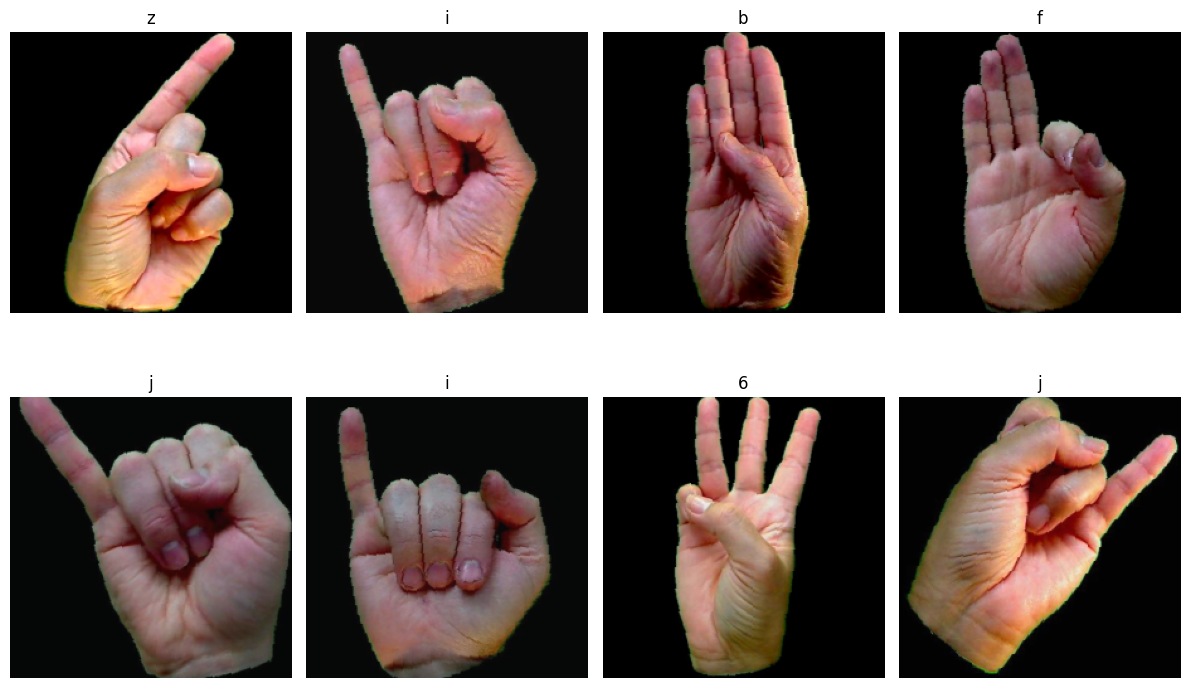

In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    show_image_tensor(images[i], title=class_names[labels[i].item()])
plt.tight_layout()
plt.show()

## Model Architecture

In [9]:
# model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# model.fc = nn.Linear(model.fc.in_features, num_classes)
# model = model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [10]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Model Training

In [11]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )
    val_loss, val_acc, y_true, y_pred = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, MODEL_SAVE_PATH)
        print(f"Best model saved to {MODEL_SAVE_PATH}")

print("Training complete.")
print("Best validation accuracy:", best_val_acc)

Epoch [1/10]
Train Loss: 1.2232 | Train Acc: 0.6252
Val   Loss: 0.6121 | Val   Acc: 0.7813
Best model saved to /workspace/best_asl_resnet18.pth
Epoch [2/10]
Train Loss: 0.2677 | Train Acc: 0.9051
Val   Loss: 0.4043 | Val   Acc: 0.8588
Best model saved to /workspace/best_asl_resnet18.pth
Epoch [3/10]
Train Loss: 0.1542 | Train Acc: 0.9473
Val   Loss: 0.6095 | Val   Acc: 0.7913
Epoch [4/10]
Train Loss: 0.1562 | Train Acc: 0.9438
Val   Loss: 0.6905 | Val   Acc: 0.8310
Epoch [5/10]
Train Loss: 0.0984 | Train Acc: 0.9637
Val   Loss: 0.3468 | Val   Acc: 0.9284
Best model saved to /workspace/best_asl_resnet18.pth
Epoch [6/10]
Train Loss: 0.0820 | Train Acc: 0.9717
Val   Loss: 0.3155 | Val   Acc: 0.9165
Epoch [7/10]
Train Loss: 0.1076 | Train Acc: 0.9637
Val   Loss: 0.1902 | Val   Acc: 0.9463
Best model saved to /workspace/best_asl_resnet18.pth
Epoch [8/10]
Train Loss: 0.0680 | Train Acc: 0.9751
Val   Loss: 0.5475 | Val   Acc: 0.8310
Epoch [9/10]
Train Loss: 0.0746 | Train Acc: 0.9742
Val   Lo

## Model Validation

Validation Loss: 0.12761468053323255
Validation Accuracy: 0.9781312127236581

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       0.78      1.00      0.88        14
           3       1.00      1.00      1.00        14
           4       1.00      1.00      1.00        14
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        14
           9       1.00      1.00      1.00        14
           a       1.00      1.00      1.00        14
           b       1.00      1.00      1.00        14
           c       1.00      1.00      1.00        14
           d       0.78      1.00      0.88        14
           e       1.00      1.00      1.00        14
           f       0.93      1.00

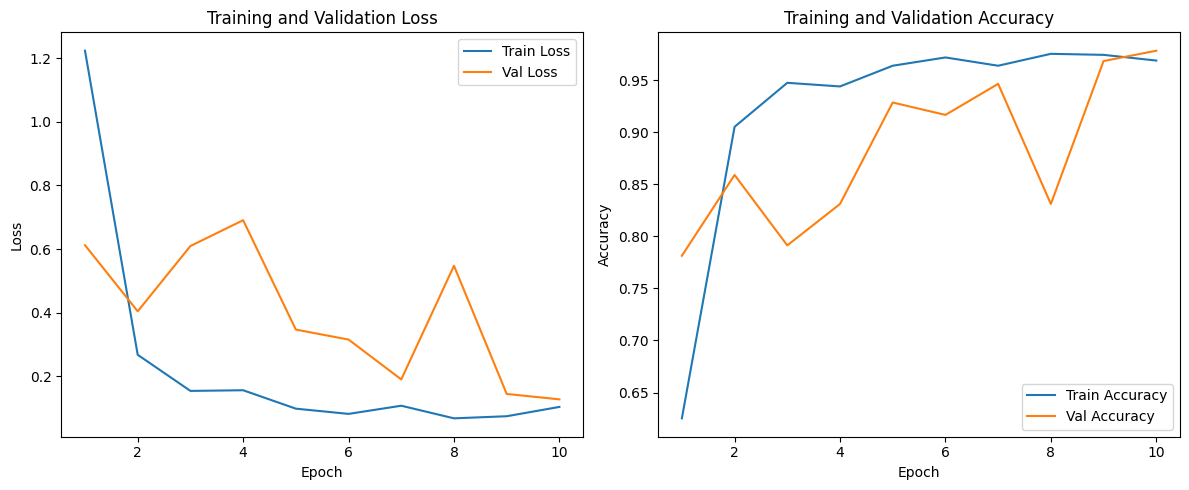

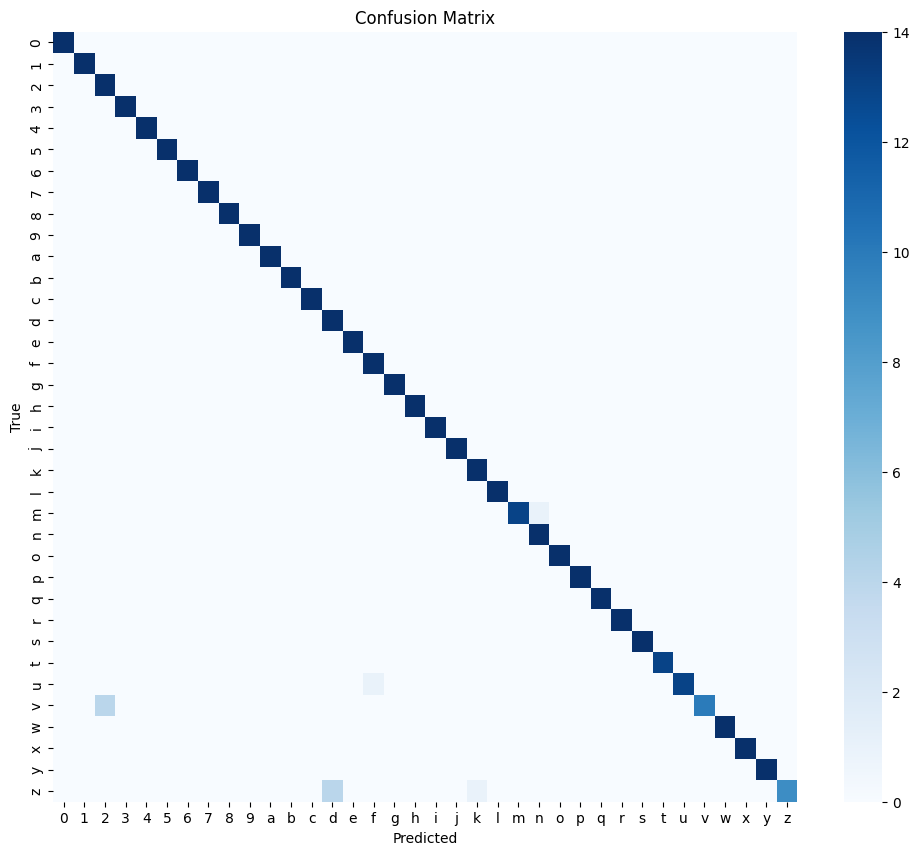

In [12]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

val_loss, val_acc, y_true, y_pred = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

plot_training_history(history)
plot_confusion_matrix(y_true, y_pred, class_names)

## Model Output

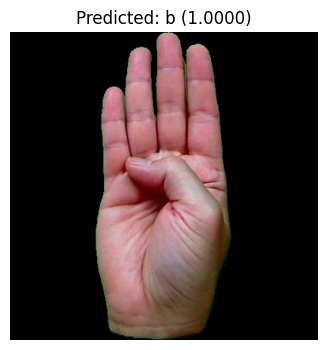

Predicted class: b
Prediction confidence: 0.9999982118606567
Actual class: b


In [13]:
sample_class = random.choice(class_names)
sample_class_dir = os.path.join(DATA_PATH, sample_class)

image_files = [
    f for f in os.listdir(sample_class_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

sample_image = os.path.join(sample_class_dir, random.choice(image_files))

predicted_class, predicted_prob = predict(
    image_path=sample_image,
    model=model,
    transform=val_transform,
    class_names=class_names,
    device=device
)

print("Predicted class:", predicted_class)
print("Prediction confidence:", predicted_prob)
print("Actual class:", sample_class)